# Structured Outputs

Structured outputs are predictions or results represented in a predefined,
consistent format.

Instead of returning only a raw value such as:

    0.87

a model can return a structured result such as:

    {
        "prediction": 1,
        "probability": 0.87,
        "class_name": "Approved"
    }

Structured outputs are useful because they make machine learning results:

- easier to read
- easier to validate
- easier to store
- easier to process programmatically
- more reliable for downstream applications

In this notebook, we will learn how structured outputs can be created,
validated, and used with machine learning models.

## What Are Structured Outputs?

A structured output is an output that follows a predefined format or schema.

For example, suppose a classification model predicts whether a customer
will churn.

An unstructured output might be:

    "The customer is likely to churn."

A structured output could be:

    {
        "customer_id": 101,
        "prediction": 1,
        "class": "Churn",
        "probability": 0.91
    }

The second representation is structured because:

- each piece of information has a defined field
- each field has a specific meaning
- the output follows a predictable format
- another program can easily read the result

### General Structure

A structured output can be represented as:

    Output = {
        Field_1: Value_1,
        Field_2: Value_2,
        ...,
        Field_n: Value_n
    }

The exact fields depend on the application.

In [1]:
# Example of a simple structured output

prediction = {
    "customer_id": 101,
    "prediction": 1,
    "class": "Churn",
    "probability": 0.91
}

prediction

{'customer_id': 101, 'prediction': 1, 'class': 'Churn', 'probability': 0.91}

Here, the prediction is represented as a Python dictionary.

Each key represents a field:

- `customer_id` → identifies the customer
- `prediction` → numerical prediction
- `class` → human-readable class
- `probability` → model confidence

This is much easier for another program to process than a plain text
sentence.

## Why Do We Need Structured Outputs?

Machine learning systems are often part of larger software systems.

For example:

    User Input
        ↓
    Machine Learning Model
        ↓
    Prediction
        ↓
    Database / API / Application

If the model returns inconsistent outputs, the downstream system may fail.

### Example

Suppose a model sometimes returns:

    "Churn"

and sometimes:

    {
        "class": "Churn",
        "probability": 0.91
    }

and sometimes:

    "The customer has a 91% chance of churning."

These outputs contain similar information, but they have different formats.

A structured output solves this problem by defining a fixed format.

For example:

    {
        "class": "Churn",
        "probability": 0.91
    }

Every prediction can now follow the same structure.

### Main Benefits

1. Consistency
2. Validation
3. Easy storage
4. Easy API integration
5. Easy downstream processing
6. Reduced ambiguity

## Structured vs Unstructured Outputs

### Unstructured Output

An unstructured output is usually plain text.

Example:

    "The model predicts that the customer will churn
     with approximately 91% probability."

A human can understand this, but a program must parse the text.

### Structured Output

A structured output has clearly defined fields.

Example:

    {
        "prediction": "Churn",
        "probability": 0.91
    }

A program can directly access:

    prediction["prediction"]

and:

    prediction["probability"]

### Comparison

| Feature | Unstructured | Structured |
|---|---|---|
| Human readability | High | High |
| Machine readability | Lower | High |
| Validation | Difficult | Easy |
| Consistency | Lower | High |
| API integration | More difficult | Easier |
| Storage | Less predictable | Predictable |

## JSON as a Structured Output Format

JSON stands for:

    JavaScript Object Notation

JSON is one of the most common formats for exchanging structured data.

A JSON object contains key-value pairs.

Example:

    {
        "name": "Alice",
        "age": 25,
        "student": true
    }

JSON supports common data types such as:

- strings
- numbers
- booleans
- arrays
- objects
- null

JSON is especially useful when machine learning models communicate with
web applications or APIs.

In [2]:
import json

prediction = {
    "prediction": "Churn",
    "probability": 0.91,
    "customer_id": 101
}

json_output = json.dumps(prediction, indent=4)

print(json_output)

{
    "prediction": "Churn",
    "probability": 0.91,
    "customer_id": 101
}


The `json.dumps()` function converts a Python object into a JSON string.

The `indent=4` argument makes the JSON easier to read.

JSON is particularly useful when sending predictions through APIs.

## Schema and Data Validation

A schema describes the expected structure of an output.

For example, we may define the following schema:

    prediction → integer
    class_name → string
    probability → float

Therefore, a valid output should look like:

    {
        "prediction": 1,
        "class_name": "Churn",
        "probability": 0.91
    }

A schema allows us to check:

- required fields
- data types
- allowed values
- numerical ranges
- nested structures

### Why Validation Matters

Suppose probability should always be between 0 and 1.

This output is invalid:

    {
        "prediction": 1,
        "probability": 1.8
    }

Validation can detect the problem before the result reaches another system.

# Structured Classification Output

We will build a classification model and convert its prediction into a
structured output.

We will use the Iris dataset.

The model will predict one of three flower classes:

- Setosa
- Versicolor
- Virginica

Instead of returning only:

    0

we will create:

    {
        "prediction": 0,
        "class_name": "setosa",
        "probability": 0.98
    }

In [3]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Load the dataset

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("Feature names:")
print(feature_names)

print("\nClass names:")
print(class_names)

print("\nDataset shape:")
print(X.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Class names:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


## Train-Test Split

We divide the dataset into:

- Training data → used to train the model
- Testing data → used to evaluate the model

We use 80% of the data for training and 20% for testing.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Feature Scaling

Logistic Regression can benefit from feature scaling.

Standardization transforms each feature approximately as:

    z = (x - μ) / σ

where:

- x = original value
- μ = mean of the feature
- σ = standard deviation

After scaling, features have approximately:

    mean = 0
    standard deviation = 1

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First scaled training sample:")
print(X_train_scaled[0])

First scaled training sample:
[-1.72156775 -0.33210111 -1.34572231 -1.32327558]


## Train Logistic Regression Model

We now train a Logistic Regression classifier.

The model learns the relationship between the flower measurements and
the target class.

In [7]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


## Evaluate the Model

In [9]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9333


In [10]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



The classification model produces a numerical class label.

For example:

    0 → setosa
    1 → versicolor
    2 → virginica

However, a numerical value alone is not always convenient.

We will now convert the prediction into a structured output.

## Create Structured Prediction

In [11]:
# Select one test sample

sample = X_test_scaled[0].reshape(1, -1)

# Prediction
prediction = model.predict(sample)[0]

# Probability for each class
probabilities = model.predict_proba(sample)[0]

# Probability of predicted class
prediction_probability = probabilities[prediction]

structured_output = {
    "prediction": int(prediction),
    "class_name": class_names[prediction],
    "probability": float(prediction_probability)
}

structured_output

{'prediction': 0,
 'class_name': np.str_('setosa'),
 'probability': 0.9788180050826786}

## Adding All Class Probabilities

For multiclass classification, it is often useful to return the probability
of every class.

For example:

    {
        "prediction": "virginica",
        "probabilities": {
            "setosa": 0.01,
            "versicolor": 0.08,
            "virginica": 0.91
        }
    }

This gives more information than returning only the predicted class.

In [12]:
structured_output = {
    "prediction": int(prediction),
    "class_name": class_names[prediction],
    "probability": float(prediction_probability),
    "class_probabilities": {
        class_names[i]: float(probabilities[i])
        for i in range(len(class_names))
    }
}

structured_output

{'prediction': 0,
 'class_name': np.str_('setosa'),
 'probability': 0.9788180050826786,
 'class_probabilities': {np.str_('setosa'): 0.9788180050826786,
  np.str_('versicolor'): 0.021181631095508892,
  np.str_('virginica'): 3.638218124906151e-07}}

## Convert Structured Output to JSON

In [13]:
json_output = json.dumps(
    structured_output,
    indent=4
)

print(json_output)

{
    "prediction": 0,
    "class_name": "setosa",
    "probability": 0.9788180050826786,
    "class_probabilities": {
        "setosa": 0.9788180050826786,
        "versicolor": 0.021181631095508892,
        "virginica": 3.638218124906151e-07
    }
}


Now the model prediction is represented as JSON.

This format can easily be:

- returned by an API
- stored in a database
- sent to a frontend application
- logged for later analysis
- consumed by another program

# Structured Regression Output

Structured outputs are not limited to classification.

They can also be used for regression.

Suppose a house-price model predicts:

    predicted_price = 8500000

Instead of returning only the number, we can return:

    {
        "prediction": 8500000,
        "unit": "INR",
        "model": "Linear Regression"
    }

We can also include additional information such as:

- input information
- prediction
- confidence information
- model name
- timestamp

In [14]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# Load regression dataset

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (442, 10)
Target shape: (442,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

y_pred = regression_model.predict(X_test)

print("Model training completed.")

Model training completed.


In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 2900.1936
RMSE: 53.8534
R² Score: 0.4526


## Create Structured Regression Output

In [18]:
sample = X_test[0].reshape(1, -1)

prediction = regression_model.predict(sample)[0]

structured_regression_output = {
    "prediction": float(prediction),
    "target": "diabetes_progression",
    "model": "Linear Regression"
}

structured_regression_output

{'prediction': 139.54755840379616,
 'target': 'diabetes_progression',
 'model': 'Linear Regression'}

The regression result is now structured.

This is useful because the prediction is accompanied by metadata describing
what the prediction represents and which model generated it.

# Using Dataclasses for Structured Outputs

Python provides `dataclasses` for creating structured objects.

A dataclass allows us to explicitly define the fields of an output.

For example:

    Prediction(
        prediction=1,
        class_name="setosa",
        probability=0.98
    )

This is more explicit than using an ordinary dictionary.

In [19]:
from dataclasses import dataclass

In [20]:
@dataclass
class ClassificationOutput:
    prediction: int
    class_name: str
    probability: float

In [21]:
output = ClassificationOutput(
    prediction=int(prediction),
    class_name="example",
    probability=0.95
)

output

ClassificationOutput(prediction=139, class_name='example', probability=0.95)

The dataclass defines the expected fields:

    prediction → int
    class_name → str
    probability → float

This makes the structure of the output explicit.

## Convert Dataclass to Dictionary

In [22]:
from dataclasses import asdict

output_dict = asdict(output)

output_dict

{'prediction': 139, 'class_name': 'example', 'probability': 0.95}

In [23]:
json_output = json.dumps(
    output_dict,
    indent=4
)

print(json_output)

{
    "prediction": 139,
    "class_name": "example",
    "probability": 0.95
}


# Pydantic for Structured Output Validation

Pydantic is a Python library commonly used for data validation.

It allows us to define:

- field names
- expected data types
- constraints
- nested structures

For example:

    prediction → integer
    class_name → string
    probability → float

Pydantic can then validate whether an output follows the expected schema.

If Pydantic is not installed in your environment, install it using:

    pip install pydantic

In [26]:
! python -m pip install pydantic

  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.5-cp314-cp314-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_inspection-0.4.4-py3-none-any.whl.metadata (2.6 kB)
Using cached pydantic-2.13.5-py3-none-any.whl (472 kB)
Using cached pydantic_core-2.46.5-cp314-cp314-win_amd64.whl (2.0 MB)
Using cached annotated_types-0.8.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.4-py3-none-any.whl (14 kB)

   ------------------------------ --------- 3/4 [pydantic]
   ------------------------------ --------- 3/4 [pydantic]
   ------------------------------ --------- 3/4 [pydantic]
   ------------------------------ --------- 3/4 [pydantic]
   ------------------------------ --------- 3/4 [pydantic]
   ------------------------------ --------- 3/4 [pydantic]
   ------------------------------ --------- 3/4 [pydantic]
   ------------------------------ --------- 3/4 [


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from pydantic import BaseModel, Field

In [28]:
class ClassificationResult(BaseModel):
    prediction: int
    class_name: str
    probability: float = Field(
        ge=0,
        le=1
    )

The `Field(ge=0, le=1)` constraint means:

    0 ≤ probability ≤ 1

Therefore, a probability such as:

    0.85

is valid.

But:

    1.50

is invalid.

In [29]:
result = ClassificationResult(
    prediction=1,
    class_name="versicolor",
    probability=0.95
)

result

ClassificationResult(prediction=1, class_name='versicolor', probability=0.95)

## Validation Example

In [30]:
try:
    invalid_result = ClassificationResult(
        prediction=1,
        class_name="versicolor",
        probability=1.5
    )
    
except Exception as error:
    print("Validation failed:")
    print(error)

Validation failed:
1 validation error for ClassificationResult
probability
  Input should be less than or equal to 1 [type=less_than_equal, input_value=1.5, input_type=float]
    For further information visit https://errors.pydantic.dev/2.13/v/less_than_equal


The invalid probability is rejected because the schema requires:

    0 ≤ probability ≤ 1

This is an important advantage of structured outputs.

Instead of allowing invalid data to move through the system, we can detect
the problem immediately.

# Nested Structured Outputs

Structured outputs can contain other structured objects.

For example:

    {
        "customer": {
            "id": 101,
            "name": "Alice"
        },
        "prediction": {
            "class": "Churn",
            "probability": 0.91
        }
    }

This is called a nested structure.

Nested structures are useful when an output contains multiple related
objects.

In [31]:
class Customer(BaseModel):
    customer_id: int
    name: str


class Prediction(BaseModel):
    class_name: str
    probability: float = Field(
        ge=0,
        le=1
    )


class CustomerPrediction(BaseModel):
    customer: Customer
    prediction: Prediction

In [32]:
result = CustomerPrediction(
    customer={
        "customer_id": 101,
        "name": "Alice"
    },
    prediction={
        "class_name": "Churn",
        "probability": 0.91
    }
)

result

CustomerPrediction(customer=Customer(customer_id=101, name='Alice'), prediction=Prediction(class_name='Churn', probability=0.91))

## Convert Nested Output to JSON

In [33]:
print(result.model_dump_json(indent=4))

{
    "customer": {
        "customer_id": 101,
        "name": "Alice"
    },
    "prediction": {
        "class_name": "Churn",
        "probability": 0.91
    }
}


The nested Pydantic model can be converted directly into JSON.

This produces a structured representation that can be transmitted through
an API or stored as structured data.

# Structured Outputs in a Machine Learning Pipeline

A complete machine learning prediction system can be represented as:

    Input Data
        ↓
    Preprocessing
        ↓
    ML Model
        ↓
    Raw Prediction
        ↓
    Structured Output
        ↓
    Validation
        ↓
    API / Database / Application

For example:

    Customer Data
        ↓
    Classification Model
        ↓
    Prediction = 1
        ↓
    Structured Result
        ↓
    Validation
        ↓
    JSON Response

## Classification Dataset

We will use the Iris dataset for our structured classification example.

The Iris dataset contains:

- 150 samples
- 4 input features
- 3 target classes

The four features are:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

The three classes are:

- Setosa
- Versicolor
- Virginica

In [37]:
from sklearn.datasets import load_iris

iris = load_iris()

X_iris = iris.data
y_iris = iris.target

iris_feature_names = iris.feature_names
iris_class_names = iris.target_names

print("Feature names:")
print(iris_feature_names)

print("\nClass names:")
print(iris_class_names)

print("\nDataset shape:")
print(X_iris.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Class names:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


In [38]:
from sklearn.model_selection import train_test_split

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

print("Training samples:", X_iris_train.shape[0])
print("Testing samples:", X_iris_test.shape[0])

Training samples: 120
Testing samples: 30


In [39]:
from sklearn.preprocessing import StandardScaler

iris_scaler = StandardScaler()

X_iris_train_scaled = iris_scaler.fit_transform(X_iris_train)
X_iris_test_scaled = iris_scaler.transform(X_iris_test)

print("Number of features:", X_iris_train_scaled.shape[1])

Number of features: 4


In [40]:
from sklearn.linear_model import LogisticRegression

iris_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

iris_model.fit(
    X_iris_train_scaled,
    y_iris_train
)

print("Model training completed.")

Model training completed.


In [41]:
from sklearn.metrics import accuracy_score, classification_report

y_iris_pred = iris_model.predict(X_iris_test_scaled)

iris_accuracy = accuracy_score(
    y_iris_test,
    y_iris_pred
)

print(f"Accuracy: {iris_accuracy:.4f}")

Accuracy: 0.9333


In [42]:
print(
    classification_report(
        y_iris_test,
        y_iris_pred,
        target_names=iris_class_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Creating a Structured Classification Prediction

We will now create a function that takes an Iris sample and returns a
structured prediction.

The output will contain:

- predicted class number
- predicted class name
- probability of the predicted class
- probability of every class

In [43]:
def predict_flower(sample):
    """
    Generate a structured prediction for an Iris flower.
    """

    # Scale the input using the Iris scaler
    sample_scaled = iris_scaler.transform(sample)

    # Generate prediction
    prediction = iris_model.predict(sample_scaled)[0]

    # Generate probabilities
    probabilities = iris_model.predict_proba(sample_scaled)[0]

    # Create structured output
    result = {
        "prediction": int(prediction),
        "class_name": iris_class_names[prediction],
        "probability": float(probabilities[prediction]),
        "class_probabilities": {
            iris_class_names[i]: float(probabilities[i])
            for i in range(len(iris_class_names))
        }
    }

    return result

In [44]:
# Select one Iris test sample

iris_sample = X_iris_test[0].reshape(1, -1)

print("Number of input features:", iris_sample.shape[1])
print("Input sample:")
print(iris_sample)

Number of input features: 4
Input sample:
[[4.4 3.  1.3 0.2]]


In [45]:
result = predict_flower(iris_sample)

result

{'prediction': 0,
 'class_name': np.str_('setosa'),
 'probability': 0.9788180050826786,
 'class_probabilities': {np.str_('setosa'): 0.9788180050826786,
  np.str_('versicolor'): 0.021181631095508892,
  np.str_('virginica'): 3.638218124906151e-07}}

In [47]:
import json

print(
    json.dumps(
        result,
        indent=4
    )
)

{
    "prediction": 0,
    "class_name": "setosa",
    "probability": 0.9788180050826786,
    "class_probabilities": {
        "setosa": 0.9788180050826786,
        "versicolor": 0.021181631095508892,
        "virginica": 3.638218124906151e-07
    }
}


## Visualizing the Structured Prediction

The structured output contains the probability assigned to each Iris class.

We can visualize these probabilities using a bar chart.

The height of each bar represents the probability predicted by the
classification model.

The three possible classes are:

- Setosa
- Versicolor
- Virginica

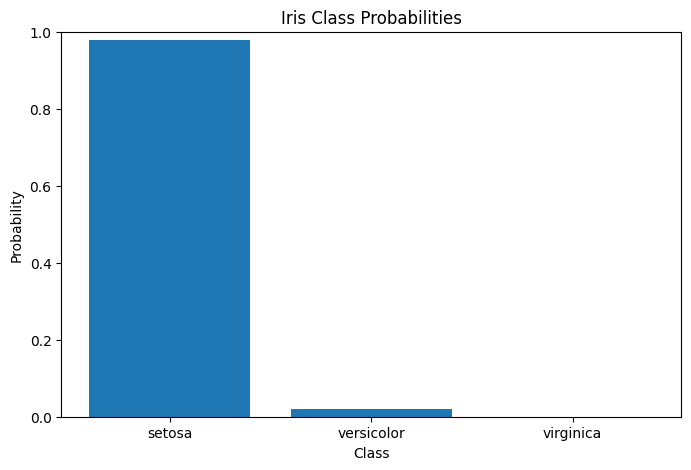

In [49]:
import matplotlib.pyplot as plt

# Scale the Iris sample
iris_sample_scaled = iris_scaler.transform(iris_sample)

# Get probabilities for each class
iris_probabilities = iris_model.predict_proba(iris_sample_scaled)[0]

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    iris_class_names,
    iris_probabilities
)

plt.xlabel("Class")
plt.ylabel("Probability")
plt.title("Iris Class Probabilities")

plt.ylim(0, 1)

plt.show()

### Interpretation

The graph shows the probability assigned to each class.

For example, suppose the model produces:

    Setosa       → 0.01
    Versicolor   → 0.08
    Virginica    → 0.91

The model predicts:

    Virginica

because Virginica has the highest probability.

Therefore:

    Predicted Class = argmax(probabilities)

The `argmax` operation selects the class with the largest predicted
probability.

In [50]:
# Find the class with the highest probability

predicted_index = iris_probabilities.argmax()

predicted_class = iris_class_names[predicted_index]

print("Predicted class:", predicted_class)
print("Probability:", iris_probabilities[predicted_index])

Predicted class: setosa
Probability: 0.9788180050826786


### Connecting the Graph with the Structured Output

The visualization and structured output represent the same model
prediction in two different ways.

The structured output is useful for programs:

    {
        "prediction": 2,
        "class_name": "virginica",
        "probability": 0.91
    }

The bar chart is useful for humans because it provides a visual
representation of the class probabilities.

Therefore, structured outputs and visualizations can complement each other.

In [51]:
# Display the final structured result

print(json.dumps(result, indent=4))

{
    "prediction": 0,
    "class_name": "setosa",
    "probability": 0.9788180050826786,
    "class_probabilities": {
        "setosa": 0.9788180050826786,
        "versicolor": 0.021181631095508892,
        "virginica": 3.638218124906151e-07
    }
}


# Summary

In this notebook, we learned about structured outputs in machine learning.

### Key Concepts

- Structured outputs follow a predefined format.
- Dictionaries can be used for simple structured results.
- JSON is widely used for exchanging structured data.
- Schemas describe the expected structure of an output.
- Dataclasses provide structured Python objects.
- Pydantic provides validation and schema enforcement.
- Structured outputs can be used for classification and regression.
- Nested structures can represent complex prediction results.
- Structured outputs are useful for APIs, databases, and ML applications.

### Important Idea

A machine learning model does not have to return only a raw prediction.

Instead of:

    prediction = 1

we can create:

    {
        "prediction": 1,
        "class_name": "versicolor",
        "probability": 0.95
    }

This makes the prediction easier for both humans and software systems
to understand and use.

# Final Takeaway

Structured outputs create a bridge between machine learning models and
real-world software systems.

The general pattern is:

    Machine Learning Model
            ↓
       Raw Prediction
            ↓
    Structured Representation
            ↓
        Validation
            ↓
      JSON / API / Database
            ↓
      Application

Therefore, structured outputs are especially important when a machine
learning model is being integrated into a larger application.

The goal is not simply to make predictions, but to produce predictions
in a reliable, consistent, and machine-readable form.